# Task 4. Predictive Modelling Using Neural Networks 

## 4.1. Additional processing

In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# clean_group_data.csv is already cleaned and encoded by dm_tools.py
df = pd.read_csv("../data/clean_group_data.csv")

# random state
rs = 42

# To ignore any future warnings
import warnings
warnings.filterwarnings("ignore")

# train test split
y = df['is_canceled']
X = df.drop(['is_canceled'], axis=1)
feature_names = X.columns
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    stratify=y, 
                                                    random_state=rs)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train, y_train)
X_test = scaler.transform(X_test)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (12068, 160)
Test shape: (3018, 160)


## 4.2. Default neural network

In [47]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(random_state=rs)
model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

print(model)
print("Iterations used:", model.n_iter_)

# keep the default network for the comparison
model_default = model

Train accuracy: 0.9119158104076898
Test accuracy: 0.7882703777335984
              precision    recall  f1-score   support

           0       0.80      0.85      0.82      1757
           1       0.77      0.70      0.74      1261

    accuracy                           0.79      3018
   macro avg       0.78      0.78      0.78      3018
weighted avg       0.79      0.79      0.79      3018

MLPClassifier(random_state=42)
Iterations used: 200


## 4.3. Tuning the network with GridSearchCV

In [48]:
params = {'hidden_layer_sizes': [(x,) for x in range(5, 161, 20)]}

# 5-fold cross validation to reduce training time
cv = GridSearchCV(param_grid=params, estimator=
                  MLPClassifier(random_state=rs), cv=5, n_jobs=-1)
cv.fit(X_train, y_train)

print("Train accuracy:", cv.score(X_train, y_train))
print("Test accuracy:", cv.score(X_test, y_test))

y_pred = cv.predict(X_test)
print(classification_report(y_test, y_pred))

print(cv.best_params_)

Train accuracy: 0.9088498508452105
Test accuracy: 0.7813121272365805
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1757
           1       0.75      0.72      0.73      1261

    accuracy                           0.78      3018
   macro avg       0.78      0.77      0.77      3018
weighted avg       0.78      0.78      0.78      3018

{'hidden_layer_sizes': (105,)}


In [49]:
# new parameters
params = {'hidden_layer_sizes': [(95,), (100,), (105,), (110,), (115,)]}

cv = GridSearchCV(param_grid=params, estimator=
                  MLPClassifier(random_state=rs), cv=5, n_jobs=-1)
cv.fit(X_train, y_train)

print("Train accuracy:", cv.score(X_train, y_train))
print("Test accuracy:", cv.score(X_test, y_test))

y_pred = cv.predict(X_test)
print(classification_report(y_test, y_pred))

print(cv.best_params_)

Train accuracy: 0.9088498508452105
Test accuracy: 0.7813121272365805
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1757
           1       0.75      0.72      0.73      1261

    accuracy                           0.78      3018
   macro avg       0.78      0.77      0.77      3018
weighted avg       0.78      0.78      0.78      3018

{'hidden_layer_sizes': (105,)}


In [50]:
params = {'hidden_layer_sizes': [(95,), (100,), (105,), (110,), (115,)], 
          'alpha': [1, 0.1, 0.01, 0.001, 0.0001]}

cv = GridSearchCV(param_grid=params, estimator=
                  MLPClassifier(max_iter=500, random_state=rs), cv=5, n_jobs=-1)
cv.fit(X_train, y_train)

print("Train accuracy:", cv.score(X_train, y_train))
print("Test accuracy:", cv.score(X_test, y_test))

y_pred = cv.predict(X_test)
print(classification_report(y_test, y_pred))

print(cv.best_params_)

# keep the tuned network
model_tuned = cv.best_estimator_
print(model_tuned)
print("Iterations used:", model_tuned.n_iter_)

KeyboardInterrupt: 

## 4.4. Neural network on the reduced feature set

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel

# best decision tree from Task 2 (GridSearchCV in decision_tree.ipynb)
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=20, max_leaf_nodes=150,
                                  min_samples_leaf=7, min_samples_split=25, random_state=rs)
dt_model.fit(X_train, y_train)

print("Task 2 DT test accuracy:", dt_model.score(X_test, y_test))

# keep the inputs with above-average importance in that tree
selectmodel = SelectFromModel(dt_model, prefit=True)
X_train_sel_model = selectmodel.transform(X_train)
X_test_sel_model = selectmodel.transform(X_test)

print(X_train_sel_model.shape)

# importance of the selected features
selected_features = feature_names[selectmodel.get_support()]
importances = pd.Series(dt_model.feature_importances_, index=feature_names)
print(importances[selected_features].sort_values(ascending=False))

Task 2 DT test accuracy: 0.7881131241714538
(10560, 13)
country_PRT                  0.289891
lead_time                    0.241205
adr                          0.123166
total_of_special_requests    0.094187
booking_changes              0.051904
arrival_date_week_number     0.042278
previous_cancellations       0.031658
arrival_date_day_of_month    0.028980
arrival_date_month_7         0.012625
adults                       0.012203
stays_in_week_nights         0.011464
country_DEU                  0.008124
stays_in_weekend_nights      0.007375
dtype: float64


In [ ]:
# hidden layer sizes from 3 up to the number of selected inputs
params = {'hidden_layer_sizes': [(x,) for x in range(3, X_train_sel_model.shape[1] + 1, 2)], 
          'alpha': [0.1, 0.01, 0.001, 0.0001]}

cv = GridSearchCV(param_grid=params, estimator=
                  MLPClassifier(max_iter=500, random_state=rs), cv=5, n_jobs=-1)
cv.fit(X_train_sel_model, y_train)

print("Train accuracy:", cv.score(X_train_sel_model, y_train))
print("Test accuracy:", cv.score(X_test_sel_model, y_test))

y_pred = cv.predict(X_test_sel_model)
print(classification_report(y_test, y_pred))

print(cv.best_params_)

# keep the feature-selected network
model_fs = cv.best_estimator_
print(model_fs)
print("Iterations used:", model_fs.n_iter_)

Train accuracy: 0.7952651515151515
Test accuracy: 0.794962439239947
              precision    recall  f1-score   support

           0       0.79      0.89      0.83      2635
           1       0.81      0.67      0.73      1891

    accuracy                           0.79      4526
   macro avg       0.80      0.78      0.78      4526
weighted avg       0.80      0.79      0.79      4526

{'alpha': 0.1, 'hidden_layer_sizes': (11,)}
MLPClassifier(alpha=0.1, hidden_layer_sizes=(11,), max_iter=500,
              random_state=42)
Iterations used: 317


## 4.5. Comparing the neural networks

In [ ]:
from sklearn.metrics import roc_auc_score

y_pred_proba_default = model_default.predict_proba(X_test)
y_pred_proba_tuned = model_tuned.predict_proba(X_test)
y_pred_proba_fs = model_fs.predict_proba(X_test_sel_model)

roc_index_default = roc_auc_score(y_test, y_pred_proba_default[:, 1])
roc_index_tuned = roc_auc_score(y_test, y_pred_proba_tuned[:, 1])
roc_index_fs = roc_auc_score(y_test, y_pred_proba_fs[:, 1])

print("ROC index on test for default NN:", roc_index_default)
print("ROC index on test for tuned NN:", roc_index_tuned)
print("ROC index on test for feature-selected NN:", roc_index_fs)

ROC index on test for default NN: 0.835980581140868
ROC index on test for tuned NN: 0.8527764091767956
ROC index on test for feature-selected NN: 0.8531155769313747


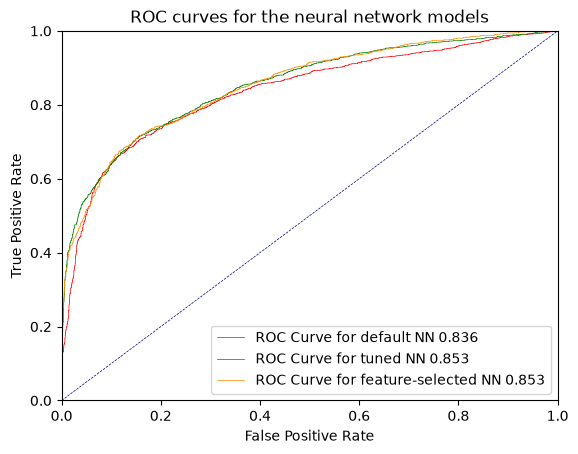

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_default, tpr_default, thresholds_default = roc_curve(y_test, y_pred_proba_default[:,1])
fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(y_test, y_pred_proba_tuned[:,1])
fpr_fs, tpr_fs, thresholds_fs = roc_curve(y_test, y_pred_proba_fs[:,1])

plt.plot(fpr_default, tpr_default, label='ROC Curve for default NN {:.3f}'.format(roc_index_default), color='red', lw=0.5)
plt.plot(fpr_tuned, tpr_tuned, label='ROC Curve for tuned NN {:.3f}'.format(roc_index_tuned), color='green', lw=0.5)
plt.plot(fpr_fs, tpr_fs, label='ROC Curve for feature-selected NN {:.3f}'.format(roc_index_fs), color='darkorange', lw=0.5)

plt.plot([0, 1], [0, 1], color='navy', lw=0.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves for the neural network models')
plt.legend(loc="lower right")
plt.show()

# Task 5. Applying the best neural network to the individual test sets

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_individual_dataset(model, dataset_path, model_name="Model"):
    # Load dataset
    individual_test = pd.read_csv(dataset_path)

    # Split features and target (same column order as the group data)
    X_individual = individual_test[feature_names]
    y_individual = individual_test["is_canceled"]

    # Same preprocessing as the group model: scale, then keep the selected inputs
    X_individual = scaler.transform(X_individual)
    X_individual = selectmodel.transform(X_individual)

    # Predictions
    y_pred = model.predict(X_individual)
    y_prob = model.predict_proba(X_individual)[:, 1]

    # Accuracy
    print("Accuracy:", accuracy_score(y_individual, y_pred))

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_individual, y_pred))

    # ROC-AUC
    auc = roc_auc_score(y_individual, y_prob)
    print("ROC-AUC:", auc)

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_individual,
        y_pred,
        display_labels=["Not Cancelled", "Cancelled"]
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_individual, y_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.3f})")
    plt.plot([0, 1], [0, 1], "--", label="Random Classifier")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.show()

### clean_test_A

Accuracy: 0.7887323943661971

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.91      0.83       289
           1       0.83      0.62      0.71       208

    accuracy                           0.79       497
   macro avg       0.80      0.77      0.77       497
weighted avg       0.80      0.79      0.78       497

ROC-AUC: 0.8320967527282407


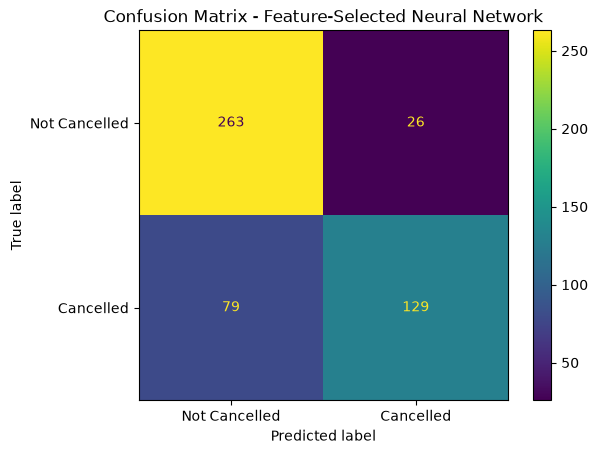

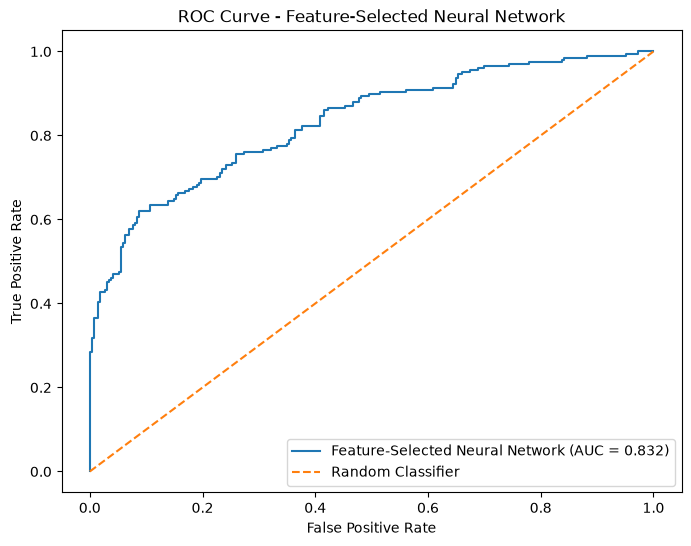

In [ ]:
evaluate_individual_dataset(
    model_fs,
    "../data/clean_test_A.csv",
    model_name="Feature-Selected Neural Network"
)

### clean_test_B

Accuracy: 0.7710843373493976

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       290
           1       0.76      0.66      0.71       208

    accuracy                           0.77       498
   macro avg       0.77      0.76      0.76       498
weighted avg       0.77      0.77      0.77       498

ROC-AUC: 0.8352785145888594


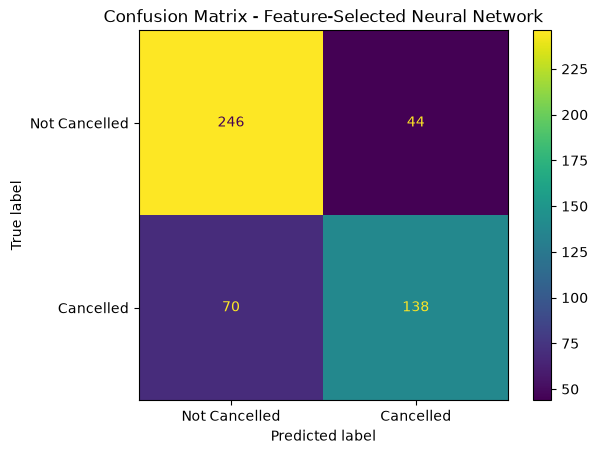

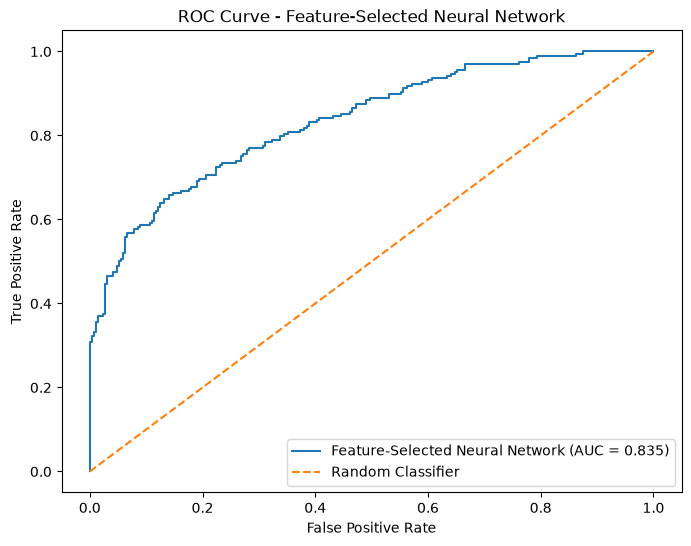

In [ ]:
evaluate_individual_dataset(
    model_fs,
    "../data/clean_test_B.csv",
    model_name="Feature-Selected Neural Network"
)

### clean_test_C

Accuracy: 0.8012048192771084

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       290
           1       0.84      0.65      0.73       208

    accuracy                           0.80       498
   macro avg       0.81      0.78      0.79       498
weighted avg       0.81      0.80      0.80       498

ROC-AUC: 0.8552967506631299


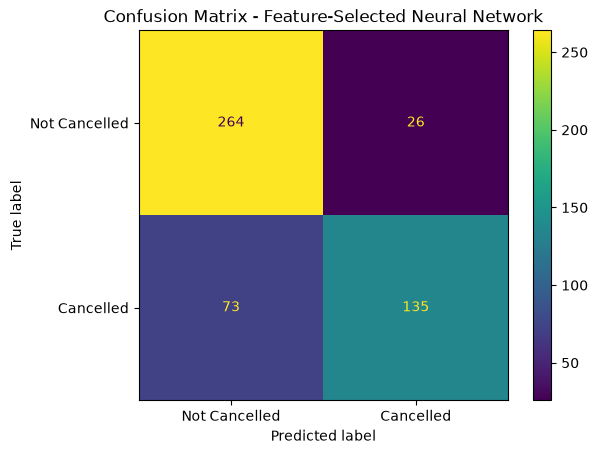

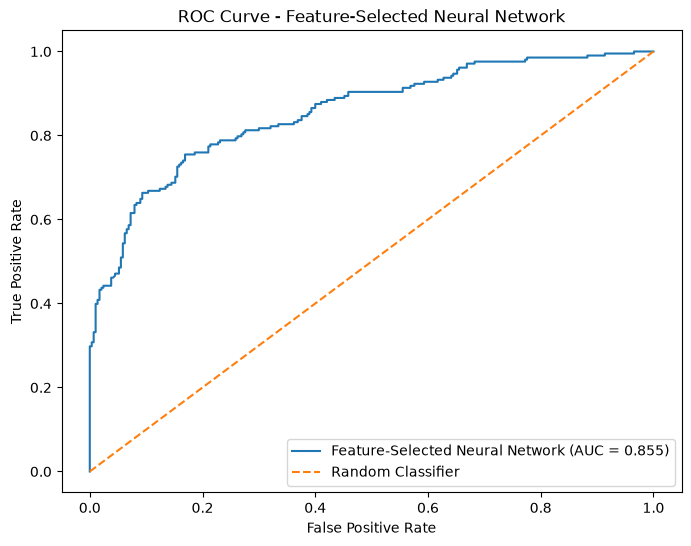

In [ ]:
evaluate_individual_dataset(
    model_fs,
    "../data/clean_test_C.csv",
    model_name="Feature-Selected Neural Network"
)